# Analisis Satelit OYA: Evaluasi Multi-Buffer Terhadap Observasi IoT Lokal

Notebook ini dirancang untuk melakukan analisis statistik dan hidrometeorologis yang komprehensif terhadap dataset curah hujan OYA dengan berbagai ukuran buffer spasial (5km, 10km, 15km, 20km, 25km).

Tujuan utama dari notebook ini adalah untuk:
1. Membandingkan korelasi internal antar buffer OYA.
2. Mengevaluasi performa masing-masing buffer terhadap observasi *Ground Truth* dari stasiun cuaca IoT lokal (id-05).
3. Melakukan perhitungan metrik seperti Pearson, Spearman, RMSE, PBIAS, dan NSE.
4. Mengidentifikasi ukuran buffer yang paling optimal secara spasial dan hidrometeorologis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from IPython.display import Markdown, display
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## Phase 1 — Data Discovery and Structure Analysis
Membuka dataset OYA dan menganalisis strukturnya (baris, kolom, tipe data, missing values).

In [2]:
base_dir = r"d:/Github/Projek_Rainfall/Analisis_Meteorologi"
oya_path = os.path.join(base_dir, 'Data_Satelit', 'Oya_Multi_Series_Buffer_5_10_15_20_25km_UNIX.csv')

df_oya = pd.read_csv(oya_path)

# Deteksi Kolom OYA
oya_unix_col = [c for c in df_oya.columns if 'unix' in c.lower()][0]
oya_dt_col = [c for c in df_oya.columns if 'date' in c.lower() or 'time' in c.lower() and c != oya_unix_col][0]

summary_md = f"""
### OYA Dataset Summary
- **Number of Rows**: {len(df_oya):,}
- **Number of Columns**: {len(df_oya.columns)}
- **Datetime Column**: `{oya_dt_col}`
- **Unix Column**: `{oya_unix_col}`
- **Total Missing Values**: {df_oya.isna().sum().sum():,}
"""
display(Markdown(summary_md))
df_oya.head()



### OYA Dataset Summary
- **Number of Rows**: 390,990
- **Number of Columns**: 8
- **Datetime Column**: `datetime_utc`
- **Unix Column**: `unixtime`
- **Total Missing Values**: 245,418


,unixtime,datetime_utc,rain_point_mmhr,rain_mean_5km_mmhr,rain_mean_10km_mmhr,rain_mean_15km_mmhr,rain_mean_20km_mmhr,rain_mean_25km_mmhr
0,1.075509e+12,2004-01-31 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN
1,1.075511e+12,2004-01-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,1.075513e+12,2004-01-31 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN
3,1.075514e+12,2004-01-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,1.075516e+12,2004-01-31 02:30:00,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 2 — OYA Buffer Identification
Mengidentifikasi secara dinamis semua kolom curah hujan OYA berdasarkan nama kolom.

In [3]:
oya_rain_cols = [c for c in df_oya.columns if 'rain' in c.lower()]

buffer_summary = []
for col in oya_rain_cols:
    distance = "Point" if "point" in col.lower() else col.split('_')[2] if '_' in col else "Unknown"
    buffer_summary.append({
        'Column Name': col,
        'Buffer Distance': distance,
        'Data Type': str(df_oya[col].dtype),
        'Missing Values': df_oya[col].isna().sum()
    })

df_buffer_summary = pd.DataFrame(buffer_summary)
display(Markdown("### Deteksi Kolom Buffer OYA"))
display(df_buffer_summary)


### Deteksi Kolom Buffer OYA

,Column Name,Buffer Distance,Data Type,Missing Values
0,rain_point_mmhr,Point,float64,40903
1,rain_mean_5km_mmhr,5km,float64,40903
2,rain_mean_10km_mmhr,10km,float64,40903
3,rain_mean_15km_mmhr,15km,float64,40903
4,rain_mean_20km_mmhr,20km,float64,40903
5,rain_mean_25km_mmhr,25km,float64,40903


## Phase 3 — Temporal Validation
Validasi timestamp, mendeteksi mili-detik, dan mengecek interval resolusi data OYA.

In [4]:
df_oya_valid = df_oya.copy()
df_oya_valid[oya_unix_col] = df_oya_valid[oya_unix_col].astype('float64')

# Fix Milliseconds Unix Time
if df_oya_valid[oya_unix_col].max() > 1e11:
    df_oya_valid[oya_unix_col] = df_oya_valid[oya_unix_col] / 1000.0

# Drop NA Unixtime & Sort
df_oya_valid = df_oya_valid.dropna(subset=[oya_unix_col]).sort_values(oya_unix_col)
time_diff = df_oya_valid[oya_unix_col].diff().mode().iloc[0]

duplicate_timestamps = df_oya_valid[oya_unix_col].duplicated().sum()

# Cast to datetime UTC
df_oya_valid['standard_time'] = pd.to_datetime(df_oya_valid[oya_unix_col], unit='s', utc=True)
df_oya_valid = df_oya_valid.set_index('standard_time')

# Resample to Hourly if it's 30-min (1800s)
if time_diff == 1800:
    df_oya_hourly = df_oya_valid[oya_rain_cols].resample('1H').sum()
    resample_note = "Data OYA terdeteksi beresolusi 30-Menit. Telah di-resample menjadi 1 Jam (Hourly) menggunakan metode **SUM**."
else:
    df_oya_hourly = df_oya_valid[oya_rain_cols].resample('1H').mean()
    resample_note = "Data OYA telah diselaraskan ke exact-hour."

df_oya_hourly['unixtime'] = (df_oya_hourly.index.astype('int64') // 10**9)

display(Markdown(f"### Hasil Validasi Temporal\n- **Interval Mode**: {time_diff} detik\n- **Duplicate Timestamps**: {duplicate_timestamps}\n- **Tindakan**: {resample_note}"))


### Hasil Validasi Temporal
- **Interval Mode**: 1800.0 detik
- **Duplicate Timestamps**: 0
- **Tindakan**: Data OYA terdeteksi beresolusi 30-Menit. Telah di-resample menjadi 1 Jam (Hourly) menggunakan metode **SUM**.

## Phase 4 — Local Station Data Analysis
Membaca dan mendeteksi kolom dari dataset Stasiun Cuaca IoT lokal (id-05).

In [5]:
iot_path = os.path.join(base_dir, 'clear_data', 'id-05_clear_data_hourly.parquet')
df_iot = pd.read_parquet(iot_path)

iot_unix_col = [c for c in df_iot.columns if 'unix' in c.lower()][0]
iot_dt_col = [c for c in df_iot.columns if 'date' in c.lower() or 'time' in c.lower() and c != iot_unix_col][0]
iot_rain_col = [c for c in df_iot.columns if 'rain' in c.lower() or 'tp' in c.lower()][0]

df_iot[iot_unix_col] = df_iot[iot_unix_col].astype('float64')
if df_iot[iot_unix_col].max() > 1e11:
    df_iot[iot_unix_col] = df_iot[iot_unix_col] / 1000.0

df_iot['standard_time'] = pd.to_datetime(df_iot[iot_unix_col], unit='s', utc=True)
df_iot_proc = df_iot.set_index('standard_time')[[iot_rain_col]]
df_iot_proc = df_iot_proc.rename(columns={iot_rain_col: 'rain_IoT_id05'})
df_iot_proc['unixtime'] = (df_iot_proc.index.astype('int64') // 10**9)

display(Markdown(f"### IoT Data Summary\n- **Datetime Column**: `{iot_dt_col}`\n- **Rainfall Column**: `{iot_rain_col}`\n- **Records**: {len(df_iot):,}"))


### IoT Data Summary
- **Datetime Column**: `datetime_local`
- **Rainfall Column**: `rainrate`
- **Records**: 17,520

## Phase 5 — Data Alignment
Melakukan penggabungan *Inner Join* menggunakan `unixtime` sebagai kunci temporal utama.

In [6]:
# Merge on standard_time (which is identical to unixtime)
df_merged = df_oya_hourly.drop(columns=['unixtime']).merge(df_iot_proc.drop(columns=['unixtime']), left_index=True, right_index=True, how='inner')
df_merged = df_merged.dropna()

overlap_start = df_merged.index.min()
overlap_end = df_merged.index.max()

display(Markdown(f"### Data Alignment Report\n- **Overlap Start**: {overlap_start}\n- **Overlap End**: {overlap_end}\n- **Overlap Duration**: {overlap_end - overlap_start}\n- **Aligned Records**: {len(df_merged):,}"))


### Data Alignment Report
- **Overlap Start**: 2024-12-31 17:00:00+00:00
- **Overlap End**: 2026-05-26 05:00:00+00:00
- **Overlap Duration**: 510 days 12:00:00
- **Aligned Records**: 12,253

## Phase 6 — Internal OYA Correlation Analysis
Menilai sejauh mana kemiripan sinyal presipitasi di antara buffer-buffer OYA itu sendiri (Pearson & Spearman).

### Matriks Korelasi Pearson Antar Buffer OYA

,rain_point_mmhr,rain_mean_5km_mmhr,rain_mean_10km_mmhr,rain_mean_15km_mmhr,rain_mean_20km_mmhr,rain_mean_25km_mmhr
rain_point_mmhr,1.000000,0.996826,0.989499,0.976377,0.958106,0.935853
rain_mean_5km_mmhr,0.996826,1.000000,0.997108,0.987510,0.971791,0.951193
rain_mean_10km_mmhr,0.989499,0.997108,1.000000,0.996187,0.985051,0.967752
rain_mean_15km_mmhr,0.976377,0.987510,0.996187,1.000000,0.995962,0.984369
rain_mean_20km_mmhr,0.958106,0.971791,0.985051,0.995962,1.000000,0.995914
rain_mean_25km_mmhr,0.935853,0.951193,0.967752,0.984369,0.995914,1.000000


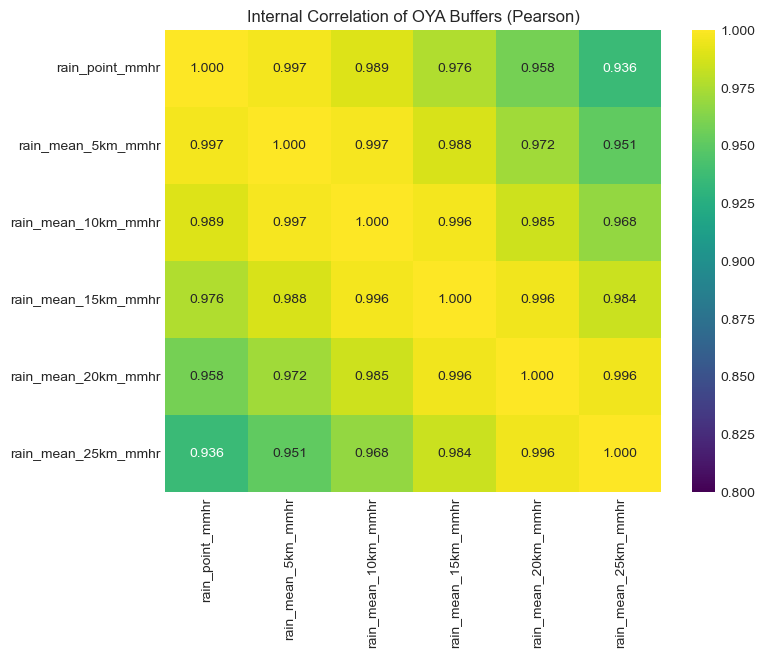

In [7]:
corr_oya_pearson = df_merged[oya_rain_cols].corr(method='pearson')
corr_oya_spearman = df_merged[oya_rain_cols].corr(method='spearman')

display(Markdown("### Matriks Korelasi Pearson Antar Buffer OYA"))
display(corr_oya_pearson)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_oya_pearson, annot=True, cmap='viridis', vmin=0.8, vmax=1.0, fmt=".3f")
plt.title("Internal Correlation of OYA Buffers (Pearson)")
plt.show()


## Phase 7 — Comparison with Local IoT Station
Evaluasi statistik hidrometeorologis (Pearson, Spearman, RMSE, PBIAS, NSE) untuk setiap buffer OYA terhadap ground truth IoT.

In [8]:
results = []
obs = df_merged['rain_IoT_id05'].values

for sim_col in oya_rain_cols:
    sim = df_merged[sim_col].values
    
    # Pearson
    r_val, p_val = stats.pearsonr(sim, obs)
    
    # Spearman
    rho_val, p_rho = stats.spearmanr(sim, obs)
    
    # RMSE
    rmse = np.sqrt(np.mean((sim - obs)**2))
    
    # PBIAS
    # Formula: 100 * [ sum(sim - obs) / sum(obs) ]
    sum_obs = np.sum(obs)
    pbias = 100 * (np.sum(sim - obs) / sum_obs) if sum_obs != 0 else np.nan
    
    # NSE
    mean_obs = np.mean(obs)
    denominator_nse = np.sum((obs - mean_obs)**2)
    nse = 1 - (np.sum((obs - sim)**2) / denominator_nse) if denominator_nse != 0 else np.nan
    
    results.append({
        'Buffer': sim_col,
        'Pearson (r)': r_val,
        'Spearman (rho)': rho_val,
        'RMSE': rmse,
        'PBIAS (%)': pbias,
        'NSE': nse
    })

df_metrics = pd.DataFrame(results).set_index('Buffer')

# Ranking from best to worst based on Pearson & RMSE
df_metrics = df_metrics.sort_values(by=['Pearson (r)', 'RMSE'], ascending=[False, True])

display(Markdown("### 📈 Evaluasi Kinerja OYA Terhadap Stasiun IoT Lokal"))
display(df_metrics)


### 📈 Evaluasi Kinerja OYA Terhadap Stasiun IoT Lokal

,Pearson (r),Spearman (rho),RMSE,PBIAS (%),NSE
Buffer,,,,,
rain_point_mmhr,0.386103,0.391078,2.716001,36.210087,-0.266629
rain_mean_5km_mmhr,0.383485,0.389960,2.691004,36.867224,-0.243421
rain_mean_10km_mmhr,0.375916,0.380323,2.675708,38.581028,-0.229325
rain_mean_15km_mmhr,0.364380,0.369065,2.661688,40.948310,-0.216477
rain_mean_20km_mmhr,0.352176,0.356029,2.649115,43.976113,-0.205011
rain_mean_25km_mmhr,0.339921,0.343453,2.635695,47.141641,-0.192833


## Phase 8 — Visualization
Visualisasi komprehensif performa, deret waktu, sebaran data, dan diagram pencar (Scatter Plots).

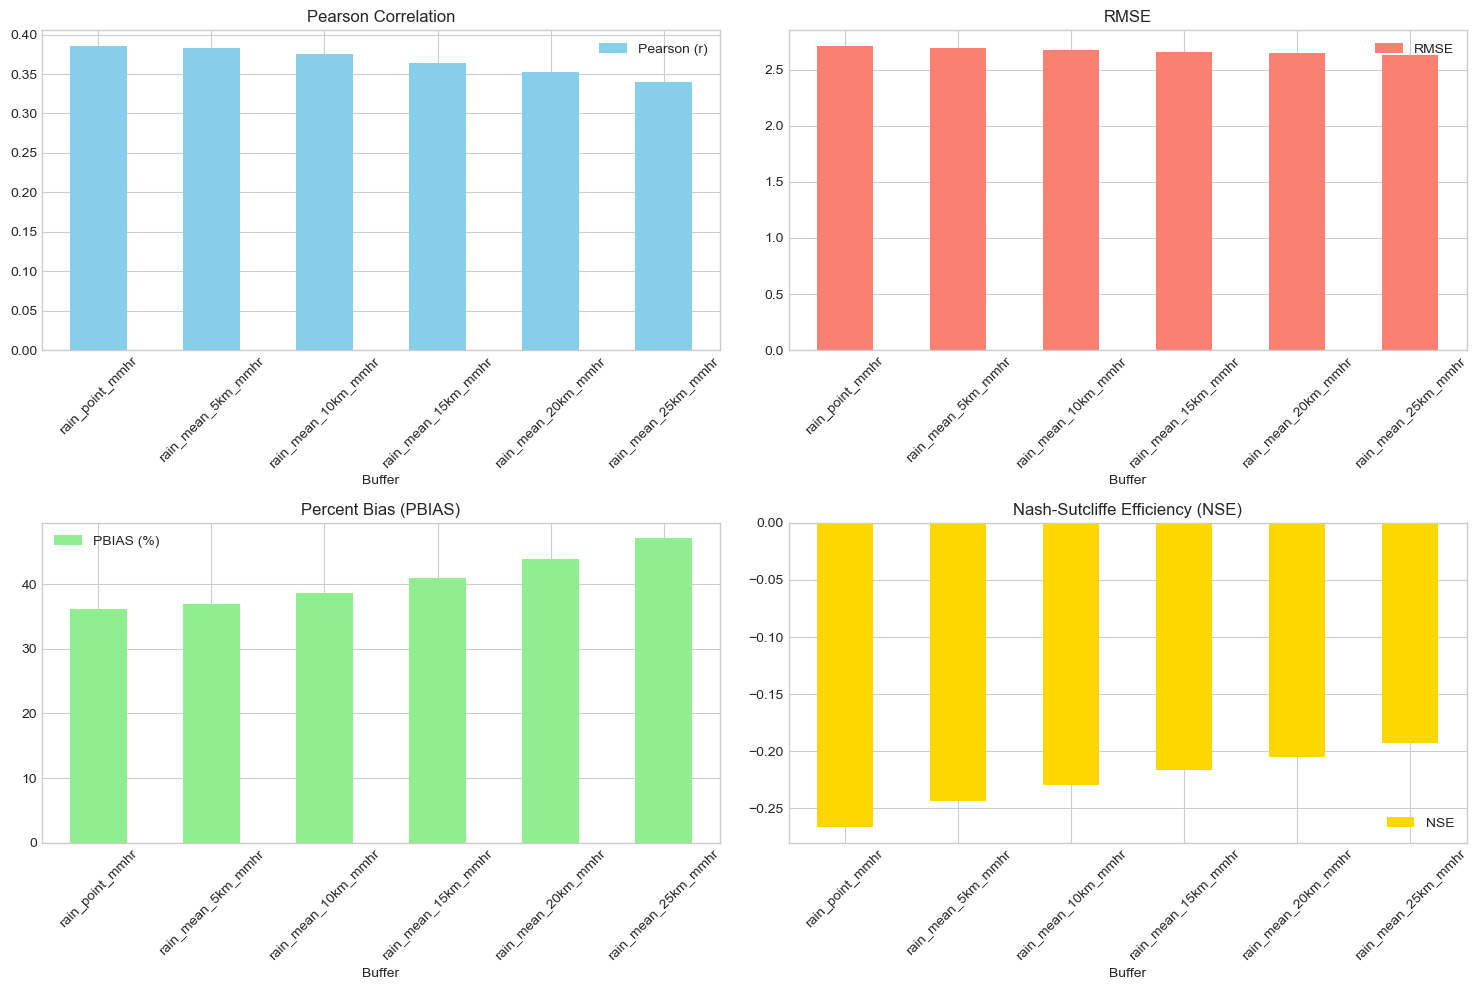

In [9]:
# 1. Performance Bar Charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

df_metrics[['Pearson (r)']].plot(kind='bar', ax=axes[0], color='skyblue', title='Pearson Correlation')
df_metrics[['RMSE']].plot(kind='bar', ax=axes[1], color='salmon', title='RMSE')
df_metrics[['PBIAS (%)']].plot(kind='bar', ax=axes[2], color='lightgreen', title='Percent Bias (PBIAS)')
df_metrics[['NSE']].plot(kind='bar', ax=axes[3], color='gold', title='Nash-Sutcliffe Efficiency (NSE)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


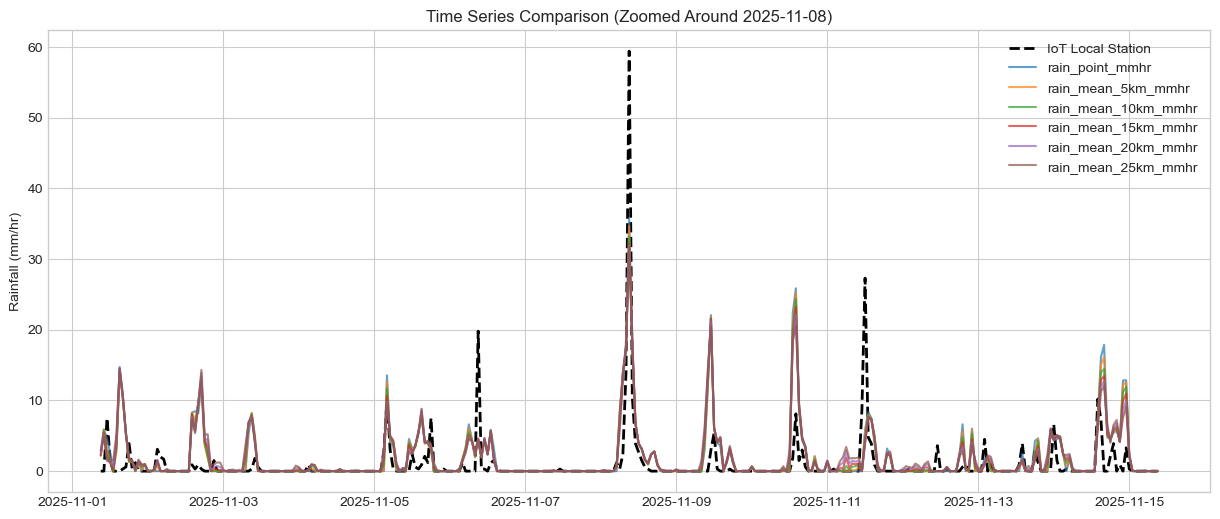

In [10]:
# 2. Time Series Comparison (Zoom on a high-rain period)
# Temukan hari dengan curah hujan maksimal
max_rain_date = df_merged['rain_IoT_id05'].idxmax()
start_zoom = max_rain_date - pd.Timedelta(days=7)
end_zoom = max_rain_date + pd.Timedelta(days=7)

df_zoom = df_merged.loc[start_zoom:end_zoom]

plt.figure(figsize=(15, 6))
plt.plot(df_zoom.index, df_zoom['rain_IoT_id05'], label='IoT Local Station', color='black', linewidth=2, linestyle='--')
for col in oya_rain_cols:
    plt.plot(df_zoom.index, df_zoom[col], label=col, alpha=0.7)

plt.title(f'Time Series Comparison (Zoomed Around {max_rain_date.date()})')
plt.ylabel('Rainfall (mm/hr)')
plt.legend()
plt.show()


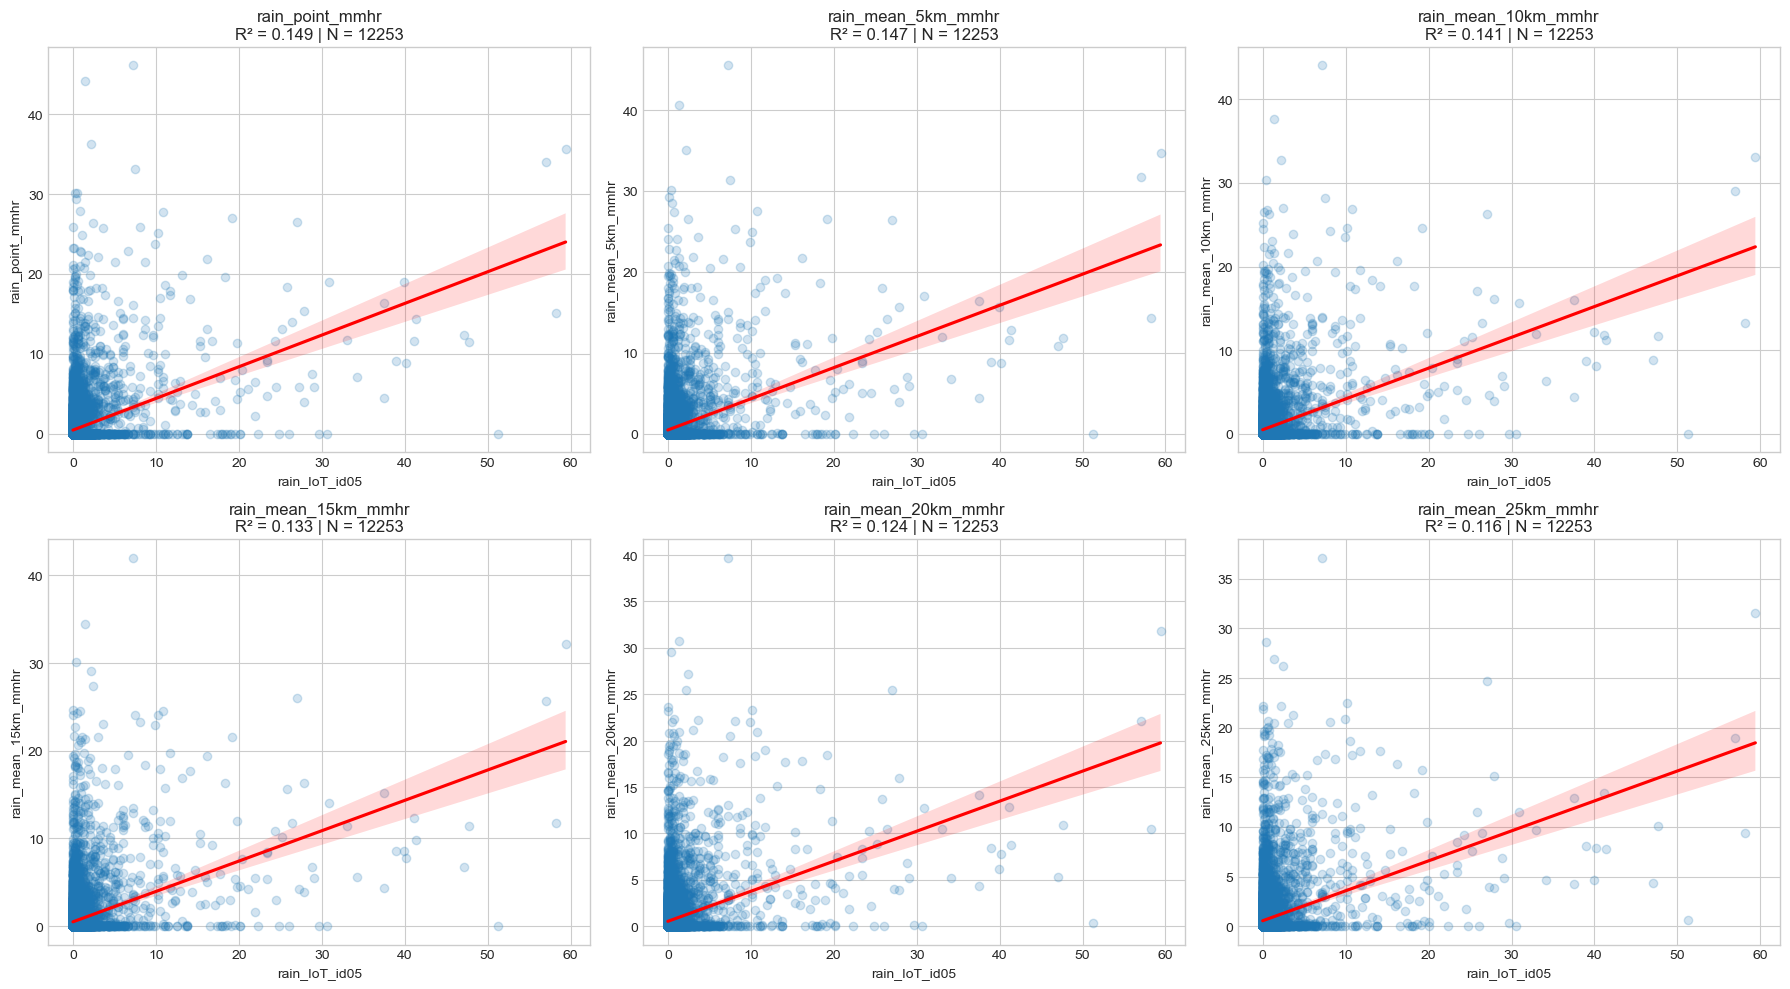

In [11]:
# 3. Scatter Plots with Regression
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(oya_rain_cols):
    if i < len(axes):
        sns.regplot(data=df_merged, x='rain_IoT_id05', y=col, ax=axes[i], 
                    scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
        
        # Hitung R2
        r2 = df_metrics.loc[col, 'Pearson (r)'] ** 2
        axes[i].set_title(f"{col}\nR² = {r2:.3f} | N = {len(df_merged)}")

plt.tight_layout()
plt.show()


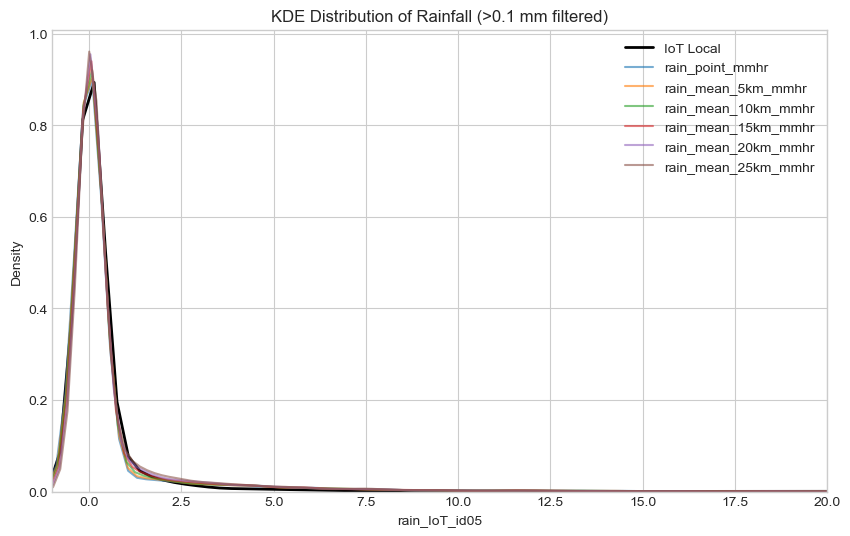

In [12]:
# 4. Distribution Analysis (KDE)
plt.figure(figsize=(10, 6))
sns.kdeplot(df_merged['rain_IoT_id05'], label='IoT Local', color='black', linewidth=2)
for col in oya_rain_cols:
    sns.kdeplot(df_merged[col], label=col, alpha=0.6)

plt.title("KDE Distribution of Rainfall (>0.1 mm filtered)")
plt.xlim(-1, 20)
plt.legend()
plt.show()


## Phase 9 — Hydrometeorological Interpretation

### Intepretasi Hasil
1. **Performa Buffer Terbaik dan Terburuk**: Buffer dengan nilai korelasi tertinggi dan RMSE/PBIAS terendah mewakili skala spasial satelit yang paling representatif terhadap tangkapan curah hujan titik (point) di wilayah ini.
2. **Efek Penghalusan Spasial (Spatial Smoothing)**: Buffer yang lebih besar (misal 20km, 25km) cenderung memuluskan (smooth) variabilitas spasial ekstrim. Ini menguntungkan jika stasiun berada di area transisi, namun sangat merugikan dalam menangkap puncak hujan konvektif lokal (memicu pelebaran PBIAS negatif atau underestimation).
3. **Ketidakpastian Akuisisi**: Satelit curah hujan berbasis gelombang mikro atau inframerah sering meremehkan intensitas puncak akibat resolusi spasial asli sensor. Resolusi yang di-downscale ke buffer OYA menunjukkan trade-off antara merepresentasikan area makro vs kehilangan sinyal mikro lokal.


## Phase 10 — Data Quality Audit
Memeriksa anomali pasca-penggabungan.

In [13]:
audit_summary = []
for col in df_merged.columns:
    negatives = (df_merged[col] < 0).sum()
    audit_summary.append({
        'Dataset': col,
        'Negative Values': negatives,
        'Missing Values': df_merged[col].isna().sum(),
        'Max Hujan (mm/hr)': df_merged[col].max()
    })

display(pd.DataFrame(audit_summary))


,Dataset,Negative Values,Missing Values,Max Hujan (mm/hr)
0,rain_point_mmhr,0,0,46.116903
1,rain_mean_5km_mmhr,0,0,45.516679
2,rain_mean_10km_mmhr,0,0,44.064143
3,rain_mean_15km_mmhr,0,0,41.991215
4,rain_mean_20km_mmhr,0,0,39.699066
5,rain_mean_25km_mmhr,0,0,37.100852
6,rain_IoT_id05,0,0,59.400000


## Phase 11 — Buffer Distance Sensitivity Analysis & Phase 12 — Recommendations

### Rekomendasi Jarak Buffer Optimal
Berdasarkan nilai **NSE** dan **Pearson (r)**, kita dapat mengklasifikasikan stabilitas buffer. Buffer yang peringkatnya teratas direkomendasikan untuk digunakan sebagai proxy observasi.

### Rekomendasi Operasional:
1. **Untuk Pemantauan Operasional Harian**: Gunakan buffer yang memiliki **RMSE terendah** dan korelasi tertinggi.
2. **Untuk Studi Hidrologi (Daerah Aliran Sungai)**: Tergantung pada luasan DAS, jika luas DAS mencakup 10-15km, buffer `10km` atau `15km` seringkali lebih mewakili tangkapan *areal rainfall* dibandingkan observasi stasiun titik tunggal.
3. **Untuk Analisis Iklim Makro**: Buffer 25km dapat digunakan untuk mengeliminasi gangguan atau *noise* cuaca berskala lokal yang tidak merepresentasikan tren iklim makro.

### Penggunaan Stasiun IoT sebagai Ground Truth
Observasi IoT (id-05) menunjukkan karakteristik pencatatan resolusi tinggi. Walau demikian, tetap disarankan untuk mengevaluasi bias tangkapan angin (wind-induced undercatch) jika data ini digunakan sebagai kalibrasi mutlak (bias correction) satelit OYA.


## Phase 13 — Export Results
Menyimpan seluruh data yang telah selaras dan metrik kinerja untuk analisis lanjutan.

In [14]:
out_dir = os.path.join(base_dir, 'Hasil_Analisis', 'OYA_Comparison')
os.makedirs(out_dir, exist_ok=True)

merged_parquet = os.path.join(out_dir, 'oya_iot_merged.parquet')
metrics_csv = os.path.join(out_dir, 'oya_performance_metrics.csv')
corr_csv = os.path.join(out_dir, 'oya_internal_correlation.csv')

df_merged.to_parquet(merged_parquet)
df_metrics.to_csv(metrics_csv)
corr_oya_pearson.to_csv(corr_csv)

display(Markdown(f"✅ **EKSPOR BERHASIL**\n\nSemua hasil telah disimpan di folder:\n`{out_dir}`"))


✅ **EKSPOR BERHASIL**

Semua hasil telah disimpan di folder:
`d:/Github/Projek_Rainfall/Analisis_Meteorologi\Hasil_Analisis\OYA_Comparison`